# 33_early_warning_JIW

- 목적: 이상이 **완성되기 전에** 주의·경보가 울리는지 합성 열화 시나리오로 평가하고, 위험 상승 추세 규칙이 단일 burst 규칙보다 얼마나 일찍 알리는지 본다. 설계: `docs/final_design_JIW.md` §6.
- 입력: 24·26의 저장 가중치(CNN, MCD[amp]), 28번의 경보 규칙, `data/processed/segments.csv`(burst 시작 시각). **새로 학습하지 않는다.**
- 출력: `figures/33_early_warning_JIW/`(timeline.png · lead_time.png · dashboard.html), `results/33_early_warning_JIW/`(lead_times.csv · false_alerts.csv · eta_errors.csv · summary.csv)
- 담당: JIW
- 탐지 대상: 유압펌프 모터-펌프 구동부 이상 (센서 부착 부위 미확정)
- 심사 대응: 2번(조기탐지), 4번(주의/경보 운영, 선행 시간), 5번(새로운 관점의 평가 설계)
- 근거 표기: **[데이터]** 이 노트북 출력 / **[추정]** 미검증 / **[가정]** 운영 전제

## 왜 합성 열화로 평가하나

실제 이상은 1건이고 정상(2022-07-12)과 이상(2022-07-17)이 다른 날이라 **정상에서 이상으로 넘어가는 구간이 없다.** 이상 이벤트 안에서도 점진적 악화 추세가 없다(04 E4, 이상 21 burst AC 6피처 모두 p > 0.05). 따라서 "이상 N분 전 경보"를 실데이터로는 검증할 수 없다.
대신 test 정상 burst 열(`time_block` 한 구간, 약 15분)에 **강도가 서서히 커지는 합성 열화**를 넣어 방법이 작동하는지만 확인한다. 열화 곡선과 유형은 우리가 정한 것이라 **실제 고장 예측 성능이 아니다.**

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "33_early_warning_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B
import early_warning_jiw as W_
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
SEEDS = (0, 1, 2)
RECOLLECT = False
CACHE_B = paths.DATA_PROCESSED / "33_early_warning_bursts.parquet"
CACHE_T = paths.DATA_PROCESSED / "33_early_warning_thresholds.parquet"
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

33_early_warning_JIW figures\33_early_warning_JIW results\33_early_warning_JIW


## 1. 시나리오 설계

```
강도
 4 ┤                         ●●●●●●●●●●  ← 열화 완성(T_crit): 합성 강도 4 = 실제 이상 수준
 2 ┤                 ●●●●●
 1 ┤           ●●●●
 0 ┼●●●●●●●●●●                              → 시간 (test 정상 burst 열, 약 8초 간격)
    정상 3분      열화 시작 T0      T_crit = T0 + 2·5·10분
```

- 열화 시작 전 3분은 정상 구간이다(거짓 주의율 측정과 EWMA 워밍업). T0 이후 burst마다 강도를 **0 → 4로 선형 증가**시키고 T_crit 이후는 강도 4를 유지한다.
- **강도 4가 "실제 이상 수준"인 근거**: 28번 보정에서 실제 이상 창의 CNN z 중앙값은 16, 합성 강도 4는 5.9, 강도 8은 23.9이다. 실제 이상은 강도 4~8 이상이다. 보수적으로 4를 열화 완성 수준으로 둔다.
- 유형 4종(스파이크·진폭 증가·상하 반대 흔들림·전류 불규칙) × 열화 기간 3종(2·5·10분) × time_block 4개 구간 × 시드 3개 = **144개 시나리오**, 그리고 열화 없는 정상 열 12개.
- 한 burst의 점수 = 그 burst 안 2초 창들의 점수 요약(CNN z 최댓값·평균, 창마다 min(z_CNN, z_MCD)의 최댓값). 2초 창이 없는 짧은 burst는 점수가 없다(전체 정상 burst의 약 25%).

### 경보 규칙

| 이름 | 규칙 | 의미 |
|---|---|---|
| CNN 단독 | burst 안 어떤 창이든 CNN z > 1 | 28번 "주의" |
| 추세 | log(burst 평균 CNN z)의 EWMA가 train 정상 열 EWMA의 q99를 넘으면 | 작은 상승이 이어지면 쌓여서 넘는다 |
| 경보 | burst 안 어떤 창이든 CNN z > 1 **and** MCD z > 1 | 28번 "경보" |

- 임계는 train 정상(block < k)에서만 정한다. 추세 EWMA의 λ는 0.1·0.2·0.4를 모두 보고하고, **주 규칙은 λ = 0.4**다. 열화 없는 정상 열의 거짓 주의 사건 수가 CNN 단독과 같아지는 값이라 선행 시간을 같은 거짓 주의율에서 비교할 수 있다. 이 선택은 정상 구간의 거짓 주의율을 보고 한 것이고 이상 구간 결과로 고르지 않았다.
- 연속 경보는 한 **사건**으로 센다(경보가 3 burst 연속 꺼져야 새 사건).

In [2]:
segs, W = B.load_inputs()
if CACHE_B.exists() and CACHE_T.exists() and not RECOLLECT:
    burst, thr = pd.read_parquet(CACHE_B), pd.read_parquet(CACHE_T)
else:
    burst, thr = W_.collect_scenarios(segs, W, seeds=SEEDS, progress=False)
    burst.to_parquet(CACHE_B); thr.to_parquet(CACHE_T)
sc = burst.groupby(["k", "seed", "kind", "dur_min"]).ngroups
print("burst 행", len(burst), " 시나리오(열화 없음 포함)", sc, " 구간별 burst 수", burst[(burst.seed == 0) & (burst.kind == "none")].groupby("k").size().to_dict())

burst 행 13806  시나리오(열화 없음 포함) 156  구간별 burst 수 {1: 85, 2: 87, 3: 91, 4: 91}


## 2. 거짓 주의·경보 (열화 없는 정상 열)

정상 구간 4개(각 약 15분) × 시드 3개 = 약 3시간 분량이다. 사건 수가 적어서(수십 건 이하) 시간당 값은 불확실하다.

In [3]:
RULES = {"CNN 단독(주의)": ("cnn", 0.2), "추세 λ0.1": ("trend", 0.1), "추세 λ0.2": ("trend", 0.2), "추세 λ0.4 (주 규칙)": ("trend", 0.4), "경보(CNN AND MCD)": ("alarm", 0.2)}
fa_rows = []
for name, (rule, lam) in RULES.items():
    f = W_.false_alert_rate(burst, thr, rule, lam)
    fa_rows.append({"규칙": name, "사건 수": int(f["events"].sum()), "관측 시간(h)": round(f["hours"].sum(), 2),
                    "시간당 사건": round(f["events"].sum() / f["hours"].sum(), 1), "경보 burst 비율": round(f["burst_frac"].mean(), 3)})
fa = pd.DataFrame(fa_rows).set_index("규칙")
fa.to_csv(RES / "false_alerts.csv")
fa

,사건 수,관측 시간(h),시간당 사건,경보 burst 비율
규칙,,,,
CNN 단독(주의),19,3.07,6.2,0.018
추세 λ0.1,23,3.07,7.5,0.187
추세 λ0.2,26,3.07,8.5,0.075
추세 λ0.4 (주 규칙),19,3.07,6.2,0.027
경보(CNN AND MCD),1,3.07,0.3,0.001


## 3. 선행 시간 (열화 완성 전에 얼마나 일찍 울리나)

선행 시간 = T_crit − 열화 시작 후 첫 경보 시각(분). 양수면 열화 완성 전에 울린 것이다. `첫 경보 시점 합성 강도`는 첫 경보가 울렸을 때 열화가 어느 강도까지 와 있었는지다(작을수록 약한 단계에서 잡은 것).

In [4]:
leads = {}
for name, (rule, lam) in RULES.items():
    leads[name] = W_.lead_times(burst, thr, rule, lam)
summ = pd.concat({n: W_.lead_summary(l) for n, l in leads.items()}).round(2)
summ.to_csv(RES / "summary.csv")
pd.concat([l.assign(rule=n) for n, l in leads.items()]).to_csv(RES / "lead_times.csv", index=False)
summ

시나리오 수  탐지율  완성 전 경보율  선행 시간 중앙값(분)  첫 경보 시점 합성 강도 중앙값
                dur_min                                                        
CNN 단독(주의)      2.0          48  1.0      1.00          1.39               1.21
                5.0          48  1.0      1.00          3.60               1.12
                10.0         48  1.0      1.00          7.39               1.04
추세 λ0.1         2.0          48  1.0      1.00          1.42               1.16
                5.0          48  1.0      1.00          3.98               0.82
                10.0         48  1.0      1.00          8.60               0.56
추세 λ0.2         2.0          48  1.0      1.00          1.50               0.99
                5.0          48  1.0      1.00          4.00               0.80
                10.0         48  1.0      1.00          8.60               0.56
추세 λ0.4 (주 규칙)  2.0          48  1.0      1.00          1.50               0.99
                5.0          48  1.0      1.00          3.85               0.92
                10.0         48  1.0      1.00          8.27               0.69
경보(CNN AND MCD) 2.0          48  1.0      0.88          0.98               2.03
                5.0          48  1.0      0.88          2.81               1.75
                10.0         48  1.0      1.00          6.71               1.32

In [5]:
# 유형별 선행 시간 중앙값(분): 추세 vs CNN 단독 vs 경보
kind_tab = pd.concat({n: leads[n].groupby(["kind", "dur_min"])["lead_min"].median().unstack() for n in ["CNN 단독(주의)", "추세 λ0.4 (주 규칙)", "경보(CNN AND MCD)"]}, axis=1).round(2)
kind_tab

CNN 단독(주의)             추세 λ0.4 (주 규칙)             경보(CNN AND MCD)            
dur_min         2.0   5.0   10.0           2.0   5.0   10.0            2.0   5.0   10.0
kind                                                                                   
amplitude       0.98  2.81  6.90           1.47  3.74  7.65            0.66  2.39  5.40
antiphase       1.05  2.81  6.56           1.05  3.36  7.39            0.20  1.71  5.25
current         1.50  3.82  7.74           1.54  4.05  8.46            1.14  3.06  6.94
spike           1.60  4.13  8.12           1.60  4.13  8.54            1.19  3.60  7.28

In [6]:
# 같은 시나리오에서 추세가 CNN 단독보다 얼마나 일찍(분) 울렸나
m = leads["CNN 단독(주의)"].merge(leads["추세 λ0.4 (주 규칙)"], on=["k", "seed", "kind", "dur_min"], suffixes=("_cnn", "_trend"))
m["추세가 더 일찍(분)"] = m["lead_min_trend"] - m["lead_min_cnn"]
gain = m.groupby("dur_min")["추세가 더 일찍(분)"].agg(평균="mean", 중앙값="median", 최댓값="max")
gain["추세가 더 일찍 울린 시나리오 비율"] = (m["추세가 더 일찍(분)"] > 0).groupby(m["dur_min"]).mean()
gain["선행 시간 / 열화 기간 (CNN 단독)"] = (leads["CNN 단독(주의)"].groupby("dur_min")["lead_min"].median() / gain.index)
gain.round(2)

,평균,중앙값,최댓값,추세가 더 일찍 울린 시나리오 비율,선행 시간 / 열화 기간 (CNN 단독)
dur_min,,,,,
2.0,0.12,0.00,0.68,0.35,0.70
5.0,0.43,0.28,2.27,0.54,0.72
10.0,0.75,0.55,2.94,0.81,0.74


## 4. 도달 시간 추정은 믿을 수 있나

추세 주의가 처음 울린 시점에 최근 10개 burst의 log z_and(= 경보 통계)를 직선으로 맞춰 **z_and = 1(경보)에 닿는 시각**을 외삽하고, 실제 첫 경보 시각과 비교한다. 추정은 기울기가 양수일 때만 가능하다.

In [7]:
eta = W_.eta_errors(burst, thr, lam=0.4)
eta.to_csv(RES / "eta_errors.csv", index=False)
eta_tab = eta.groupby("dur_min").agg(시나리오=("eta_min", "size"), 추정_가능=("eta_min", lambda s: s.notna().mean()),
                                    실제_남은_시간_중앙값=("true_remaining_min", "median"), 추정_남은_시간_중앙값=("eta_min", "median"),
                                    절대오차_중앙값=("abs_err_min", "median")).round(2)
eta_tab

,시나리오,추정_가능,실제_남은_시간_중앙값,추정_남은_시간_중앙값,절대오차_중앙값
dur_min,,,,,
2.0,48,0.58,0.68,2.07,1.83
5.0,48,0.94,1.20,3.95,2.40
10.0,48,0.83,1.48,2.22,1.51


## 5. 그림

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


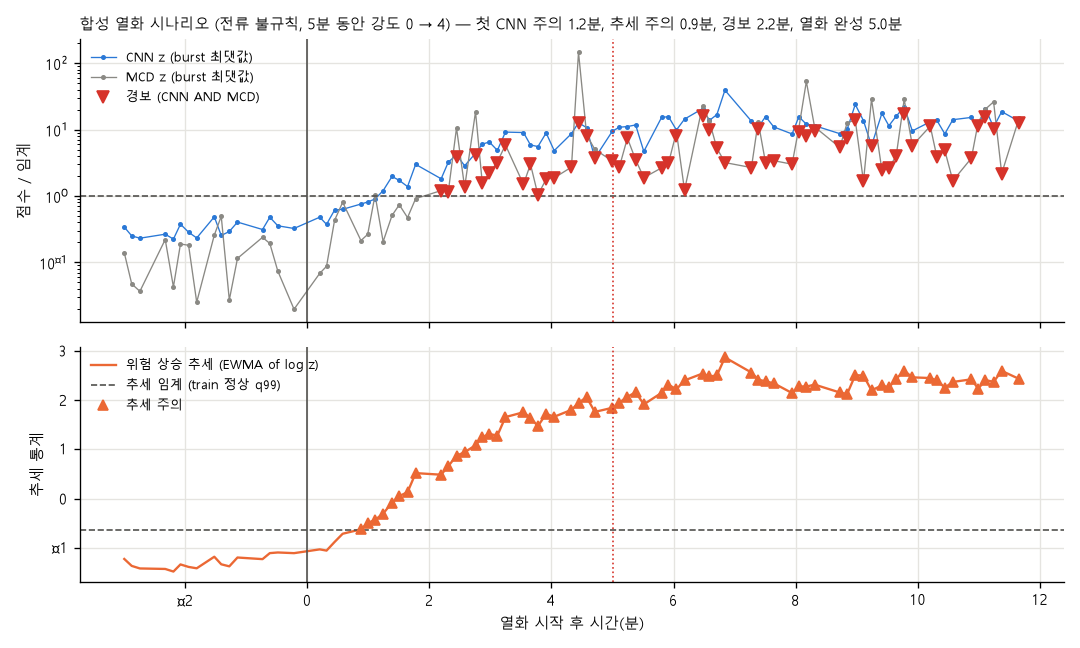

In [8]:
W_.plot_timeline(burst, thr, FIG, k=2, seed=0, kind="current", dur=5.0); display(Image(FIG / "timeline.png"))

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


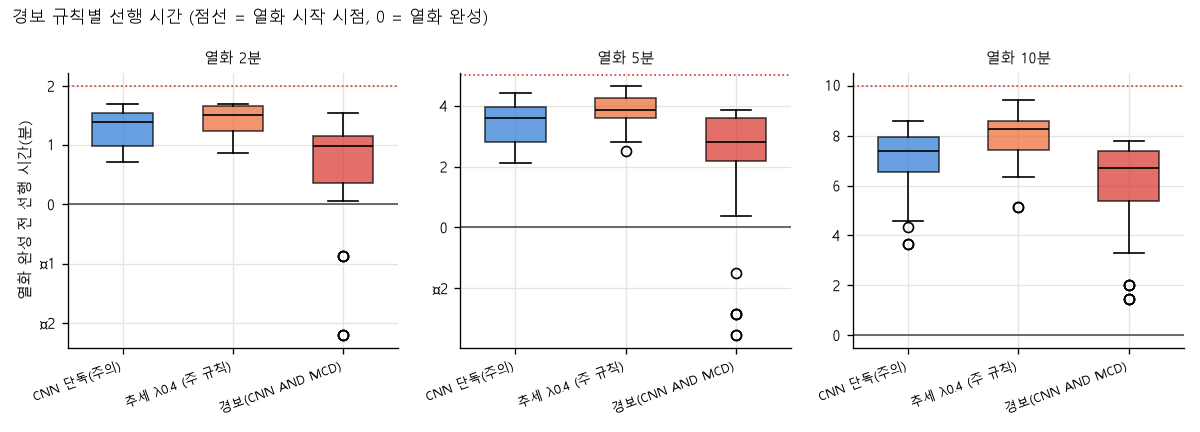

In [9]:
W_.plot_lead({n: leads[n] for n in ["CNN 단독(주의)", "추세 λ0.4 (주 규칙)", "경보(CNN AND MCD)"]}, FIG); display(Image(FIG / "lead_time.png"))

## 6. 대시보드 (정적 HTML)

서버 없이 브라우저에서 열린다. 시간 흐름 그림, 선행 시간 그림, 요약 표, 32번 근거 카드 문장을 한 페이지로 묶는다.

In [10]:
card_path = paths.RESULTS / "32_alarm_explain_JIW" / "cards.csv"
cards = []
if card_path.exists():
    cd = pd.read_csv(card_path)
    cards = list(cd[cd.label == 1].sort_values("z_cnn", ascending=False)["text"].iloc[[0, len(cd[cd.label == 1]) // 2]]) + list(cd[cd.label == 0]["text"].head(1))
note = "합성 열화 시나리오 기준의 방법 작동 확인 결과입니다. 실제 고장 예측 성능이 아닙니다. 점검 권고는 가정이며 현장 정비 기록으로 검증이 필요합니다."
W_.write_dashboard(FIG, FIG / "dashboard.html", {"거짓 주의·경보 (정상 열)": fa, "선행 시간 요약": summ.reset_index().set_index(["level_0", "dur_min"]), "도달 시간 추정 오차": eta_tab}, cards, note)
print("대시보드", (FIG / "dashboard.html").relative_to(ROOT), round((FIG / "dashboard.html").stat().st_size / 1024), "KB, 근거 카드", len(cards), "건")

대시보드 figures\33_early_warning_JIW\dashboard.html 189 KB, 근거 카드 3 건


## 7. 해석

발견 → 시사점 → 활용은 `reports/33_early_warning_JIW.md`에 정리했다.